In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation
from tqdm import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using compute device: {device}")

Using compute device: mps


In [2]:
BASE_DIR = "../01_data/model_ready_production"

train_transform = A.Compose([
    A.Resize(1024, 1024), 
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ToTensorV2() 
])

val_transform = A.Compose([
    A.Resize(1024, 1024), 
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ToTensorV2() 
])

class ProductionHabitatDataset(Dataset):
    def __init__(self, split, transform=None):
        self.img_dir = os.path.join(BASE_DIR, split, "images")
        self.mask_dir = os.path.join(BASE_DIR, split, "masks")
        self.transform = transform
        self.images = sorted(os.listdir(self.img_dir))
        
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)
        
        with rasterio.open(img_path) as src_img:
            image = src_img.read()
            image = np.transpose(image, (1, 2, 0)) 
            
        with rasterio.open(mask_path) as src_mask:
            mask = src_mask.read(1)
            
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        mask = mask.to(torch.long)
        return image, mask

train_dataset = ProductionHabitatDataset('train', transform=train_transform)
val_dataset = ProductionHabitatDataset('val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

print(f"Loaded {len(train_dataset)} Train images and {len(val_dataset)} Validation images.")

Loaded 3782 Train images and 330 Validation images.


## TODO: 
I will need to replace focal loss with cross entropy loss and increase learning rate slighty.

In [3]:
# Focal Loss Implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, ignore_index=255):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
        self.ce = nn.CrossEntropyLoss(weight=alpha, ignore_index=ignore_index, reduction='none')

    def forward(self, logits, targets):
        log_pt = self.ce(logits, targets)
        pt = torch.exp(-log_pt)
        focal_loss = ((1 - pt) ** self.gamma) * log_pt
        return focal_loss.mean()

def calculate_iou(preds, labels, num_classes, ignore_index=255):
    ious = []
    preds = preds.view(-1)
    labels = labels.view(-1)
    valid_mask = (labels != ignore_index)
    preds = preds[valid_mask]
    labels = labels[valid_mask]
    
    for cls in range(num_classes):
        intersection = ((preds == cls) & (labels == cls)).sum().item()
        union = ((preds == cls) | (labels == cls)).sum().item()
        if union > 0:
            ious.append(intersection / union)
    return sum(ious) / len(ious) if ious else 0.0

# Model Initialization
id2label = {
    0: 'Impervious / Built-up', 1: 'Forest & Dense Canopy', 2: 'Urban Trees & Bushes',
    3: 'Managed Green Spaces', 4: 'Standard Grassland', 5: 'Ecologically Valuable Meadow',
    6: 'Agriculture & Orchards', 7: 'Water Bodies'
}
label2id = {v: k for k, v in id2label.items()}

# We use the B0 model again as a baseline, but you can upgrade to 'nvidia/mit-b1' if your M4 Max handles this easily!
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0", num_labels=len(id2label), id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True
).to(device)

# Production Training Setup
weights = torch.tensor([1.0, 5.0, 2.0, 2.0, 5.0, 3.0, 10.0, 10.0]).float().to(device)
loss_fn = FocalLoss(alpha=weights, gamma=2.0, ignore_index=255)

optimizer = optim.AdamW(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3) # Slightly higher patience for larger dataset

epochs = 50
patience = 7
best_miou = 0.0
epochs_no_improve = 0

# SIMULATE BATCH SIZE 16 (4 real images * 4 accumulation steps)
accumulation_steps = 4 

history_train_loss = []
history_val_miou = []

print("Model and training configuration initialized.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Model and training configuration initialized.


In [4]:
print(f" Starting Production Training on {device} with Gradient Accumulation...")

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs} | LR: {optimizer.param_groups[0]['lr']}")
    
    # TRAINING PHASE
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    
    for i, (images, masks) in enumerate(tqdm(train_loader, desc="Training Batches")):
        images, masks = images.to(device), masks.to(device)
        
        outputs = model(pixel_values=images)
        upsampled_logits = F.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        
        loss = loss_fn(upsampled_logits, masks)
        # Normalize the loss based on accumulation steps
        loss = loss / accumulation_steps 
        loss.backward() # Accumulate the gradients
        
        # Only update the weights every 4 steps
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
            
        running_loss += loss.item() * accumulation_steps # Un-normalize for logging
        
    avg_loss = running_loss / len(train_loader)
    history_train_loss.append(avg_loss)
    print(f"Average Training Loss: {avg_loss:.4f}")
    
    # VALIDATION PHASE 
    model.eval()
    running_miou = 0.0
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation Batches"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(pixel_values=images)
            upsampled_logits = F.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
            preds = upsampled_logits.argmax(dim=1)
            running_miou += calculate_iou(preds, masks, num_classes=8)
            
    avg_miou = running_miou / len(val_loader)
    history_val_miou.append(avg_miou)
    print(f"Validation mIoU: {avg_miou * 100:.2f}%")
    
    # SCHEDULER & CHECKPOINTING
    scheduler.step(avg_miou)
    
    if avg_miou > best_miou:
        best_miou = avg_miou
        epochs_no_improve = 0
        os.makedirs("../02_models/production_segformer", exist_ok=True)
        model.save_pretrained("../02_models/production_segformer") 
        print(" New best model saved!")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs.")
        
    if epochs_no_improve >= patience:
        print(f"\n Early stopping triggered! Production Training Complete. Best mIoU: {best_miou * 100:.2f}%")
        break

 Starting Production Training on mps with Gradient Accumulation...

Epoch 1/50 | LR: 0.0001


Training Batches: 100%|███████████████████████| 946/946 [10:28<00:00,  1.51it/s]


Average Training Loss: 5.1833


Validation Batches: 100%|███████████████████████| 83/83 [00:29<00:00,  2.77it/s]

Validation mIoU: 1.85%


...

Validation mIoU: 1.85%
No improvement for 6 epochs.

Epoch 8/50 | LR: 5e-05


Training Batches: 100%|███████████████████████| 946/946 [09:15<00:00,  1.70it/s]


Average Training Loss: 5.1509


Validation Batches: 100%|███████████████████████| 83/83 [00:26<00:00,  3.14it/s]

Validation mIoU: 1.85%
No improvement for 7 epochs.

 Early stopping triggered! Production Training Complete. Best mIoU: 1.85%


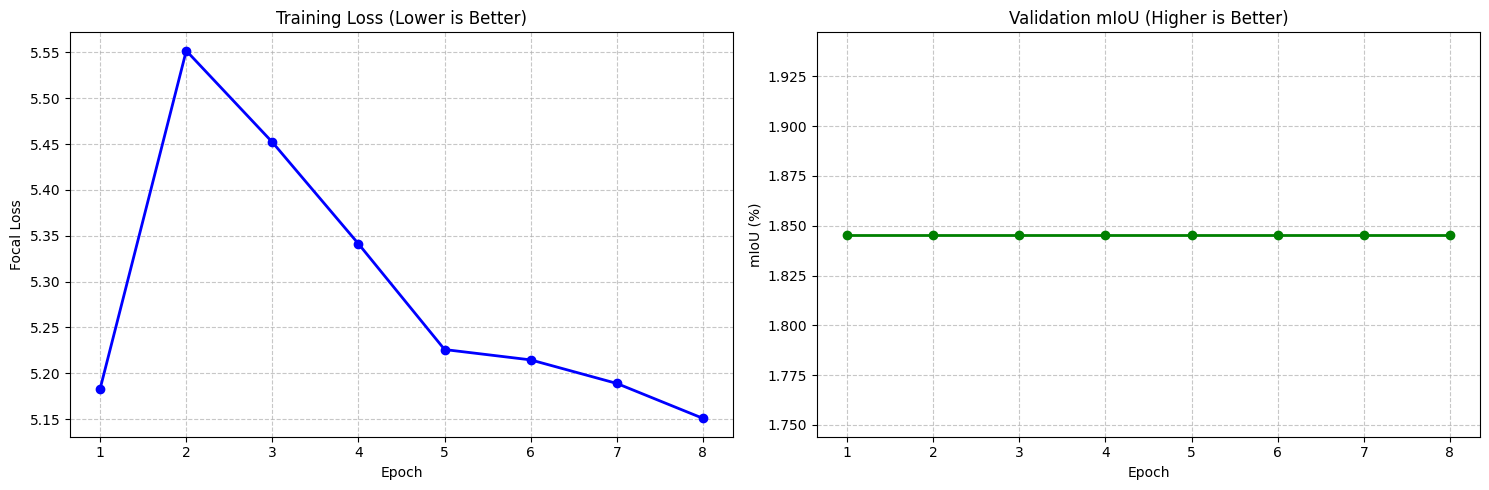

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Training Loss
ax1.plot(range(1, len(history_train_loss) + 1), history_train_loss, marker='o', color='b', linewidth=2)
ax1.set_title("Training Loss (Lower is Better)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Focal Loss")
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Validation mIoU
ax2.plot(range(1, len(history_val_miou) + 1), [m * 100 for m in history_val_miou], marker='o', color='g', linewidth=2)
ax2.set_title("Validation mIoU (Higher is Better)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("mIoU (%)")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

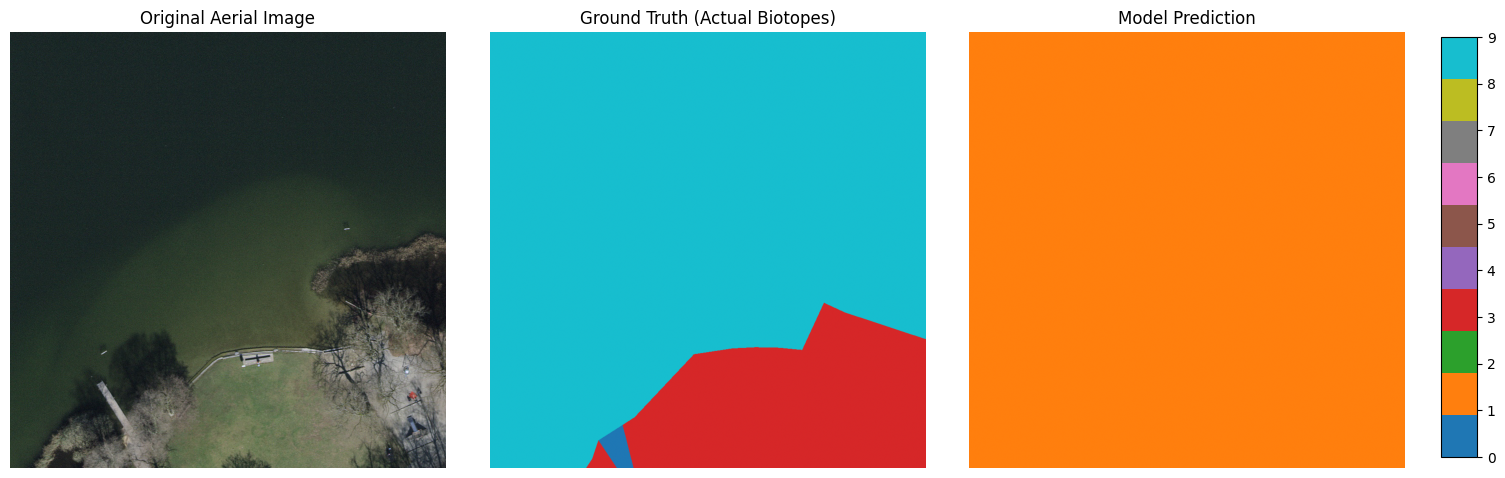

In [6]:
best_model = SegformerForSemanticSegmentation.from_pretrained("../02_models/production_segformer").to(device)
best_model.eval()

images, masks = next(iter(val_loader))
input_image = images[0].unsqueeze(0).to(device)
ground_truth = masks[0].numpy()

with torch.no_grad():
    outputs = best_model(pixel_values=input_image)
    logits = F.interpolate(
        outputs.logits, size=(1024, 1024), mode="bilinear", align_corners=False
    )
    predicted_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

img_display = images[0].numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_display)
axs[0].set_title("Original Aerial Image")
axs[0].axis('off')

axs[1].imshow(ground_truth, cmap='tab10', vmin=0, vmax=9)
axs[1].set_title("Ground Truth (Actual Biotopes)")
axs[1].axis('off')

im = axs[2].imshow(predicted_mask, cmap='tab10', vmin=0, vmax=9)
axs[2].set_title("Model Prediction")
axs[2].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
fig.colorbar(im, cax=cbar_ax)
plt.subplots_adjust(wspace=0.1, right=0.9)
plt.show()